## Import & Install Library

In [1]:
!pip install apify-client pandas gspread google-auth

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.0/87.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 58.2 MB/s eta 0:00:00


In [3]:
import pandas as pd
from apify_client import ApifyClient
import time
from google.colab import auth
from google.auth import default
import gspread

## Apify Token

In [6]:
# Autentikasi Google
auth.authenticate_user()
gc = gspread.authorize(default()[0])

In [4]:
APIFY_API_TOKEN = "apify_api_UE4kFZJ3QTfP934unHM5tXDswVC97u2Daf85"

client = ApifyClient(APIFY_API_TOKEN)
print("\u2713 Token Apify siap digunakan.")

✓ Token Apify siap digunakan.


## Baca Spreadsheet

In [7]:
def get_sheet_data(sheet_url, gid):
    """Ambil data dari Google Sheet berdasarkan URL dan GID"""
    sheet = gc.open_by_url(sheet_url)
    worksheet = sheet.get_worksheet_by_id(gid)
    data = worksheet.get_all_records()
    df = pd.DataFrame(data)
    print(f" GID {gid}: {len(df)} baris")
    return df


df_maj_wisata = get_sheet_data("https://docs.google.com/spreadsheets/d/1iMamOtEjNiuFi8NGHQ3N5J-zXUuoNyxJtjyvA2uU_rs/edit?hl=id&gid=0#gid=0",0)
df_maj_kuliner = get_sheet_data("https://docs.google.com/spreadsheets/d/1iMamOtEjNiuFi8NGHQ3N5J-zXUuoNyxJtjyvA2uU_rs/edit?hl=id&gid=0#gid=0",457861819)
df_maj_nongkrong = get_sheet_data("https://docs.google.com/spreadsheets/d/1iMamOtEjNiuFi8NGHQ3N5J-zXUuoNyxJtjyvA2uU_rs/edit?hl=id&gid=0#gid=0",2012842317)

print("\u2713 Semua sheet berhasil dibaca!")

 GID 0: 37 baris
 GID 457861819: 45 baris
 GID 2012842317: 55 baris
✓ Semua sheet berhasil dibaca!


## Ekstrak URL Google Maps

In [9]:
def extract_urls(df, kategori, wilayah):
    """Ambil URL Google Maps dari kolom Link_Google_Maps"""
    if df.empty:
        print(f" {wilayah} {kategori}: DataFrame kosong")
        return []

    if 'Link_Google_Maps' not in df.columns:
        print(f" {wilayah} {kategori}: kolom 'Link_Google_Maps' tidak ditemukan")
        print(f"   Kolom yang ada: {list(df.columns)}")
        return []

    urls = df['Link_Google_Maps'].dropna().tolist()
    urls = [str(u).strip() for u in urls if 'google.com/maps' in str(u) or 'maps.app.goo.gl' in str(u)]

    print(f"\u2713 {wilayah} {kategori}: {len(urls)} URL")
    return urls

# Urls Majalengka
urls_maj_wisata = extract_urls(df_maj_wisata, "Wisata", "Majalengka")
urls_maj_kuliner = extract_urls(df_maj_kuliner, "Kuliner", "Majalengka")
urls_maj_nongkrong = extract_urls(df_maj_nongkrong, "Nongkrong", "Majalengka")
urls_majalengka = urls_maj_wisata + urls_maj_kuliner + urls_maj_nongkrong

print(f" total: {len(urls_majalengka)} tempat")

✓ Majalengka Wisata: 37 URL
✓ Majalengka Kuliner: 45 URL
✓ Majalengka Nongkrong: 55 URL
 total: 137 tempat


## Fungsi Scraper

In [24]:
def scrape_reviews_majalengka(url_list, kategori_name, target_reviews=35):
    """
    Scrape Google Maps reviews untuk wilayah Majalengka.

    Parameters:
    -----------
    url_list : list
        Daftar URL Google Maps tempat wisata di Majalengka
    kategori_name : str
        Kategori tempat (contoh: 'Wisata', 'Kuliner', 'Nongkrong')
    target_reviews : int, default=35
        Jumlah ulasan yang diambil per tempat

    Returns:
    --------
    tuple : (reviews_raw_list, places_metadata_list)
        - reviews_raw_list: list of dict, berisi setiap ulasan (hanya yang memiliki teks)
        - places_metadata_list: list of dict, berisi ringkasan per tempat
    """

    # Validasi input
    if not url_list:
        print(f"[WARNING] Tidak ada URL untuk Majalengka - {kategori_name}")
        return [], []

    # Estimasi biaya dengan buffer 50%
    buffer_reviews = int(target_reviews * 1.5)
    estimated_cost = (len(url_list) * buffer_reviews / 1000) * 0.60
    print(f"\n[RUN] Majalengka - {kategori_name}")
    print(f"  - Jumlah tempat: {len(url_list)}")
    print(f"  - Target ulasan per tempat: {target_reviews}")
    print(f"  - Estimasi biaya: ${estimated_cost:.2f}")

    # Konversi URL ke format yang diminta Apify
    start_urls = [{"url": url} for url in url_list]

    # Konfigurasi input scraper
    actor_input = {
        "startUrls": start_urls,
        "maxReviews": buffer_reviews,
        "reviewsSort": "newest",
        "language": "id",
        "proxyConfig": {"useApifyProxy": True}
    }

    try:
        # Jalankan actor Apify
        run = client.actor("compass/google-maps-reviews-scraper").call(run_input=actor_input)

        # Ambil hasil dari dataset
        dataset = client.dataset(run["defaultDatasetId"])
        items = dataset.list_items().items

        # Inisialisasi hasil
        reviews_raw = []
        places_metadata = []
        added_places = set()

        for item in items:
            # Ambil data tempat dari item (karena 1 item = 1 ulasan)
            place_id = item.get('placeId', 'N/A')
            place_name = item.get('title', 'N/A')
            total_reviews_google = item.get('reviewsCount', 0)
            avg_rating_google = item.get('totalScore', 0.0)
            category_name_google = item.get('categoryName', 'N/A')
            categories_google = item.get('categories', [])
            latitude = item.get('location', {}).get('lat')
            longitude = item.get('location', {}).get('lng')
            scraped_at = pd.Timestamp.now().isoformat()

            # Simpan metadata tempat (hanya sekali per place_id)
            if place_id not in added_places:
                places_metadata.append({
                    'place_id': place_id,
                    'place_name': place_name,
                    'wilayah': 'Majalengka',
                    'kategori': kategori_name,
                    'category_name_google': category_name_google,
                    'categories_google': str(categories_google),
                    'latitude': latitude,
                    'longitude': longitude,
                    'total_reviews_google': total_reviews_google,
                    'avg_rating_google': avg_rating_google,
                    'total_reviews_scraped': 0,
                    'scraped_at': scraped_at
                })
                added_places.add(place_id)

            # Filter: hanya simpan ulasan yang memiliki teks (bukan None dan bukan 'None')
            review_text = item.get('text')
            if review_text and review_text != 'None' and len(str(review_text).strip()) >= 15:
                reviews_raw.append({
                    'review_id': item.get('reviewId', 'N/A'),
                    'place_id': place_id,
                    'place_name': place_name,
                    'wilayah': 'Majalengka',
                    'kategori': kategori_name,
                    'rating': item.get('stars'),
                    'review_text': review_text,
                    'review_date': item.get('publishedAtDate'),
                    'reviewer_name': item.get('name'),
                    'reviewer_id': item.get('reviewerId', 'N/A'),
                    'is_local_guide': item.get('isLocalGuide', False),
                    'likes_count': item.get('likesCount', 0),
                    'original_language': item.get('originalLanguage', 'N/A'),
                    'scraped_at': scraped_at
                })

        # Hitung total ulasan per tempat untuk metadata
        for place in places_metadata:
            place_id = place['place_id']
            place['total_reviews_scraped'] = len([r for r in reviews_raw if r['place_id'] == place_id])

        print(f"[SUCCESS] Majalengka - {kategori_name}")
        print(f"  - Tempat discrape: {len(places_metadata)}")
        print(f"  - Total ulasan berteks: {len(reviews_raw)}")
        if len(places_metadata) > 0:
            print(f"  - Rata-rata ulasan per tempat: {len(reviews_raw)/len(places_metadata):.1f}")

        return reviews_raw, places_metadata

    except Exception as e:
        print(f"[ERROR] Scraping gagal untuk Majalengka - {kategori_name}")
        print(f"  - Error: {str(e)}")
        return [], []

## Test Eksekusi

In [21]:
test_url = urls_maj_wisata[0]

reviews_test, metadata_test = scrape_reviews_majalengka(
    url_list=[test_url],
    kategori_name="test",
    target_reviews=5
)

if reviews_test:
    print("berhasil")
    print(f"jumlah ulasan: {len(reviews_test)}")
    print(f"nama tempat: {metadata_test[0]['place_name']}")
    print(f"rating: {reviews_test[0]['rating']}")
    print(f"ulasan: {reviews_test[0]['review_text']}")
else:
    print("gagal")


[RUN] Majalengka - test
  - Jumlah tempat: 1
  - Target ulasan per tempat: 5
  - Estimasi biaya: $0.00


[apify.Google-Maps-Reviews-Scraper runId:GFnKINKVuGRbyYEPo] -> Status: RUNNING, Message: 
[apify.Google-Maps-Reviews-Scraper runId:GFnKINKVuGRbyYEPo] -> 2026-05-04T16:08:11.214Z ACTOR: Pulling container image of build c3go3Yxyd9bJa2vOZ from registry.
[apify.Google-Maps-Reviews-Scraper runId:GFnKINKVuGRbyYEPo] -> 2026-05-04T16:08:11.216Z ACTOR: Creating container.
[apify.Google-Maps-Reviews-Scraper runId:GFnKINKVuGRbyYEPo] -> 2026-05-04T16:08:11.282Z ACTOR: Starting container.
[apify.Google-Maps-Reviews-Scraper runId:GFnKINKVuGRbyYEPo] -> 2026-05-04T16:08:11.283Z ACTOR: Running under "LIMITED_PERMISSIONS" permission level.
[apify.Google-Maps-Reviews-Scraper runId:GFnKINKVuGRbyYEPo] -> 2026-05-04T16:08:12.430Z INFO  System info {"apifyVersion":"3.5.3","apifyClientVersion":"2.19.0","crawleeVersion":"3.16.0","osType":"Linux","nodeVersion":"v24.15.0"}
[apify.Google-Maps-Reviews-Scraper runId:GFnKINKVuGRbyYEPo] -> 2026-05-04T16:08:12.961Z INFO  [BG ENQUEUE] Finished enqueueing
[apify.Google-

[SUCCESS] Majalengka - test
  - Tempat discrape: 1
  - Total ulasan berteks: 4
  - Rata-rata ulasan per tempat: 4.0
berhasil
jumlah ulasan: 4
nama tempat: Terasering Panyaweuyan
rating: 5
ulasan: Indah mempesona sejuk segar


In [22]:
print("Daftar Ulasan Test : ")
print("-" * 30)

for i, review in enumerate(reviews_test, 1):
    print(f"\n[i] Ulasan Ke-{i}")
    print(f"    rating    : {review['rating']} bintang")
    print(f"    reviewer  : {review['reviewer_name']}")
    print(f"    tanggal   : {review['review_date'][:10]}")

    teks = review['review_text']
    if teks and teks != 'None':
        print(f"    teks      : {teks[:200]}")
        if len(teks) > 200:
            print(f"                {teks[200:]}")
    else:
        print(f"    teks      : [tidak ada teks ulasan]")

    print("-" * 30)

Daftar Ulasan Test : 
------------------------------

[i] Ulasan Ke-1
    rating    : 5 bintang
    reviewer  : Djoko Purwanto
    tanggal   : 2026-05-02
    teks      : Indah mempesona sejuk segar
------------------------------

[i] Ulasan Ke-2
    rating    : 5 bintang
    reviewer  : Bian Toro
    tanggal   : 2026-04-30
    teks      : Pemandangan pergunungan yang bagus serta rute jalan menuju terarsering juga menantang.
------------------------------

[i] Ulasan Ke-3
    rating    : 5 bintang
    reviewer  : Evi Janti
    tanggal   : 2026-04-30
    teks      : Datang kesini masih pagi, sempat nyasar juga, jalan menuju kesana waktu itu masih jelek, tapi pemandangan sepanjang jalan sangat indah, udara juga sejuk.

Kebun bawangnya rapiii banget dan sangat bers
                ih, sayangnya wkt itu tdk semua area ditumbuhi bawang, mungkin sudah panen, jadi ada sebagian area yang gundul

Kami mampir di warung kopi disana, nongkrong2 sambil ngopi, ngemil dan menikmati view ...sambil takj

## Eksekusi

In [25]:
print("\u2713 Memulai Scraping...")

# Scraping Wisata Majalengka
reviews_wisata, metadata_wisata = scrape_reviews_majalengka(
    url_list=urls_maj_wisata,
    kategori_name="Wisata",
    target_reviews=35
)

# Scraping Kuliner Majalengka
reviews_kuliner, metadata_kuliner = scrape_reviews_majalengka(
    url_list=urls_maj_kuliner,
    kategori_name="Kuliner",
    target_reviews=35
)

# Scraping Nongkrong Majalengka
reviews_nongkrong, metadata_nongkrong = scrape_reviews_majalengka(
    url_list=urls_maj_nongkrong,
    kategori_name="Nongkrong",
    target_reviews=35
)

print("\u2713 Scraping Selesai!")
print(f"Wisata: {len(reviews_wisata)} ulasan, {len(metadata_wisata)} tempat")
print(f"Kuliner: {len(reviews_kuliner)} ulasan, {len(metadata_kuliner)} tempat")
print(f"Nongkrong: {len(reviews_nongkrong)} ulasan, {len(metadata_nongkrong)} tempat")

✓ Memulai Scraping...

[RUN] Majalengka - Wisata
  - Jumlah tempat: 37
  - Target ulasan per tempat: 35
  - Estimasi biaya: $1.15


[apify.Google-Maps-Reviews-Scraper runId:4elKDlRUNJvB0HILC] -> Status: RUNNING, Message: 
[apify.Google-Maps-Reviews-Scraper runId:4elKDlRUNJvB0HILC] -> 2026-05-04T16:17:11.987Z ACTOR: Pulling container image of build c3go3Yxyd9bJa2vOZ from registry.
[apify.Google-Maps-Reviews-Scraper runId:4elKDlRUNJvB0HILC] -> 2026-05-04T16:17:11.990Z ACTOR: Creating container.
[apify.Google-Maps-Reviews-Scraper runId:4elKDlRUNJvB0HILC] -> 2026-05-04T16:17:12.046Z ACTOR: Starting container.
[apify.Google-Maps-Reviews-Scraper runId:4elKDlRUNJvB0HILC] -> 2026-05-04T16:17:12.048Z ACTOR: Running under "LIMITED_PERMISSIONS" permission level.
[apify.Google-Maps-Reviews-Scraper runId:4elKDlRUNJvB0HILC] -> 2026-05-04T16:17:13.074Z INFO  System info {"apifyVersion":"3.5.3","apifyClientVersion":"2.19.0","crawleeVersion":"3.16.0","osType":"Linux","nodeVersion":"v24.15.0"}
[apify.Google-Maps-Reviews-Scraper runId:4elKDlRUNJvB0HILC] -> 2026-05-04T16:17:13.647Z INFO  [BG ENQUEUE] Finished enqueueing
[apify.Google-

[SUCCESS] Majalengka - Wisata
  - Tempat discrape: 33
  - Total ulasan berteks: 748
  - Rata-rata ulasan per tempat: 22.7

[RUN] Majalengka - Kuliner
  - Jumlah tempat: 45
  - Target ulasan per tempat: 35
  - Estimasi biaya: $1.40


[apify.Google-Maps-Reviews-Scraper runId:dnqsny21bC2OPjLln] -> Status: RUNNING, Message: 
[apify.Google-Maps-Reviews-Scraper runId:dnqsny21bC2OPjLln] -> 2026-05-04T16:18:38.687Z ACTOR: Pulling container image of build c3go3Yxyd9bJa2vOZ from registry.
[apify.Google-Maps-Reviews-Scraper runId:dnqsny21bC2OPjLln] -> 2026-05-04T16:18:38.690Z ACTOR: Creating container.
[apify.Google-Maps-Reviews-Scraper runId:dnqsny21bC2OPjLln] -> 2026-05-04T16:18:39.557Z ACTOR: Starting container.
[apify.Google-Maps-Reviews-Scraper runId:dnqsny21bC2OPjLln] -> 2026-05-04T16:18:39.559Z ACTOR: Running under "LIMITED_PERMISSIONS" permission level.
[apify.Google-Maps-Reviews-Scraper runId:dnqsny21bC2OPjLln] -> Status: RUNNING, Message: Starting the crawler.
[apify.Google-Maps-Reviews-Scraper runId:dnqsny21bC2OPjLln] -> 2026-05-04T16:18:41.562Z INFO  System info {"apifyVersion":"3.5.3","apifyClientVersion":"2.19.0","crawleeVersion":"3.16.0","osType":"Linux","nodeVersion":"v24.15.0"}
[apify.Google-Maps-Reviews-Scr

[SUCCESS] Majalengka - Kuliner
  - Tempat discrape: 45
  - Total ulasan berteks: 1147
  - Rata-rata ulasan per tempat: 25.5

[RUN] Majalengka - Nongkrong
  - Jumlah tempat: 55
  - Target ulasan per tempat: 35
  - Estimasi biaya: $1.72


[apify.Google-Maps-Reviews-Scraper runId:5GNYM4QT1DDcIBvw5] -> Status: RUNNING, Message: 
[apify.Google-Maps-Reviews-Scraper runId:5GNYM4QT1DDcIBvw5] -> 2026-05-04T16:20:02.389Z ACTOR: Pulling container image of build c3go3Yxyd9bJa2vOZ from registry.
[apify.Google-Maps-Reviews-Scraper runId:5GNYM4QT1DDcIBvw5] -> 2026-05-04T16:20:02.391Z ACTOR: Creating container.
[apify.Google-Maps-Reviews-Scraper runId:5GNYM4QT1DDcIBvw5] -> 2026-05-04T16:20:03.420Z ACTOR: Starting container.
[apify.Google-Maps-Reviews-Scraper runId:5GNYM4QT1DDcIBvw5] -> 2026-05-04T16:20:03.422Z ACTOR: Running under "LIMITED_PERMISSIONS" permission level.
[apify.Google-Maps-Reviews-Scraper runId:5GNYM4QT1DDcIBvw5] -> 2026-05-04T16:20:04.496Z INFO  System info {"apifyVersion":"3.5.3","apifyClientVersion":"2.19.0","crawleeVersion":"3.16.0","osType":"Linux","nodeVersion":"v24.15.0"}
[apify.Google-Maps-Reviews-Scraper runId:5GNYM4QT1DDcIBvw5] -> 2026-05-04T16:20:05.018Z INFO  [BG ENQUEUE] Finished enqueueing
[apify.Google-

[SUCCESS] Majalengka - Nongkrong
  - Tempat discrape: 55
  - Total ulasan berteks: 1391
  - Rata-rata ulasan per tempat: 25.3
✓ Scraping Selesai!
Wisata: 748 ulasan, 33 tempat
Kuliner: 1147 ulasan, 45 tempat
Nongkrong: 1391 ulasan, 55 tempat


## Simpan Hasil

In [26]:
print("\u2713 Menyimpan hasil scraping...")

# Wisata
df_reviews_wisata = pd.DataFrame(reviews_wisata)
df_metadata_wisata = pd.DataFrame(metadata_wisata)
df_reviews_wisata.to_csv('majalengka_wisata_reviews.csv', index=False, encoding='utf-8-sig')
df_metadata_wisata.to_csv('majalengka_wisata_metadata.csv', index=False, encoding='utf-8-sig')

# Kuliner
df_reviews_kuliner = pd.DataFrame(reviews_kuliner)
df_metadata_kuliner = pd.DataFrame(metadata_kuliner)
df_reviews_kuliner.to_csv('majalengka_kuliner_reviews.csv', index=False, encoding='utf-8-sig')
df_metadata_kuliner.to_csv('majalengka_kuliner_metadata.csv', index=False, encoding='utf-8-sig')

# Nongkrong
df_reviews_nongkrong = pd.DataFrame(reviews_nongkrong)
df_metadata_nongkrong = pd.DataFrame(metadata_nongkrong)
df_reviews_nongkrong.to_csv('majalengka_nongkrong_reviews.csv', index=False, encoding='utf-8-sig')
df_metadata_nongkrong.to_csv('majalengka_nongkrong_metadata.csv', index=False, encoding='utf-8-sig')

print("\u2713 File tersimpan:")
print("  - majalengka_wisata_reviews.csv")
print("  - majalengka_wisata_metadata.csv")
print("  - majalengka_kuliner_reviews.csv")
print("  - majalengka_kuliner_metadata.csv")
print("  - majalengka_nongkrong_reviews.csv")
print("  - majalengka_nongkrong_metadata.csv")

✓ Menyimpan hasil scraping...
✓ File tersimpan:
  - majalengka_wisata_reviews.csv
  - majalengka_wisata_metadata.csv
  - majalengka_kuliner_reviews.csv
  - majalengka_kuliner_metadata.csv
  - majalengka_nongkrong_reviews.csv
  - majalengka_nongkrong_metadata.csv


## Load Data

In [27]:
import pandas as pd

print("Membaca semua file csv")
print()

# Baca semua file
df_wisata_reviews = pd.read_csv('majalengka_wisata_reviews.csv')
df_wisata_metadata = pd.read_csv('majalengka_wisata_metadata.csv')

df_kuliner_reviews = pd.read_csv('majalengka_kuliner_reviews.csv')
df_kuliner_metadata = pd.read_csv('majalengka_kuliner_metadata.csv')

df_nongkrong_reviews = pd.read_csv('majalengka_nongkrong_reviews.csv')
df_nongkrong_metadata = pd.read_csv('majalengka_nongkrong_metadata.csv')

print("File berhasil dibaca")
print()

print("Data ulasan wisata")
print("-" * 35)
print(f"Jumlah ulasan: {len(df_wisata_reviews)}")
print(f"Jumlah tempat unik: {df_wisata_reviews['place_name'].nunique()}")
print(f"Kolom: {list(df_wisata_reviews.columns)}")
print()
print("5 ulasan pertama:")
print(df_wisata_reviews[['place_name', 'rating', 'review_text', 'review_date']].head())
print()

print("Data ulasan kuliner")
print("-" * 35)
print(f"Jumlah ulasan: {len(df_kuliner_reviews)}")
print(f"Jumlah tempat unik: {df_kuliner_reviews['place_name'].nunique()}")
print()
print("5 ulasan pertama:")
print(df_kuliner_reviews[['place_name', 'rating', 'review_text', 'review_date']].head())
print()

print("Data ulasan nongkrong")
print("-" * 35)
print(f"Jumlah ulasan: {len(df_nongkrong_reviews)}")
print(f"Jumlah tempat unik: {df_nongkrong_reviews['place_name'].nunique()}")
print()
print("5 ulasan pertama:")
print(df_nongkrong_reviews[['place_name', 'rating', 'review_text', 'review_date']].head())

Membaca semua file csv

File berhasil dibaca

Data ulasan wisata
-----------------------------------
Jumlah ulasan: 748
Jumlah tempat unik: 33
Kolom: ['review_id', 'place_id', 'place_name', 'wilayah', 'kategori', 'rating', 'review_text', 'review_date', 'reviewer_name', 'reviewer_id', 'is_local_guide', 'likes_count', 'original_language', 'scraped_at']

5 ulasan pertama:
      place_name  rating                                        review_text  \
0  Gunung Ciwaru       5  Bagus tempat ny cmn akses jlny rusak tp g para...   
1  Gunung Ciwaru       5                           Asikkk banget tempatnya😍   
2  Gunung Ciwaru       5  Pemandangannya bagus,adem pula pokonya bikin b...   
3  Gunung Ciwaru       4  Capek nya terbayar oleh bentangan Landscape hi...   
4  Gunung Ciwaru       5  Wisata yang sangat rekomendasi buat kalian aja...   

                review_date  
0  2026-04-23T12:25:29.419Z  
1  2026-04-21T09:07:34.750Z  
2  2026-04-18T00:41:04.096Z  
3  2026-04-15T02:05:53.365Z  
4  

## **Visualisasi statistik ulasan**

/tmp/ipykernel_6490/205407207.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax4.boxplot(data_box, labels=['Wisata', 'Kuliner', 'Nongkrong'], patch_artist=True)


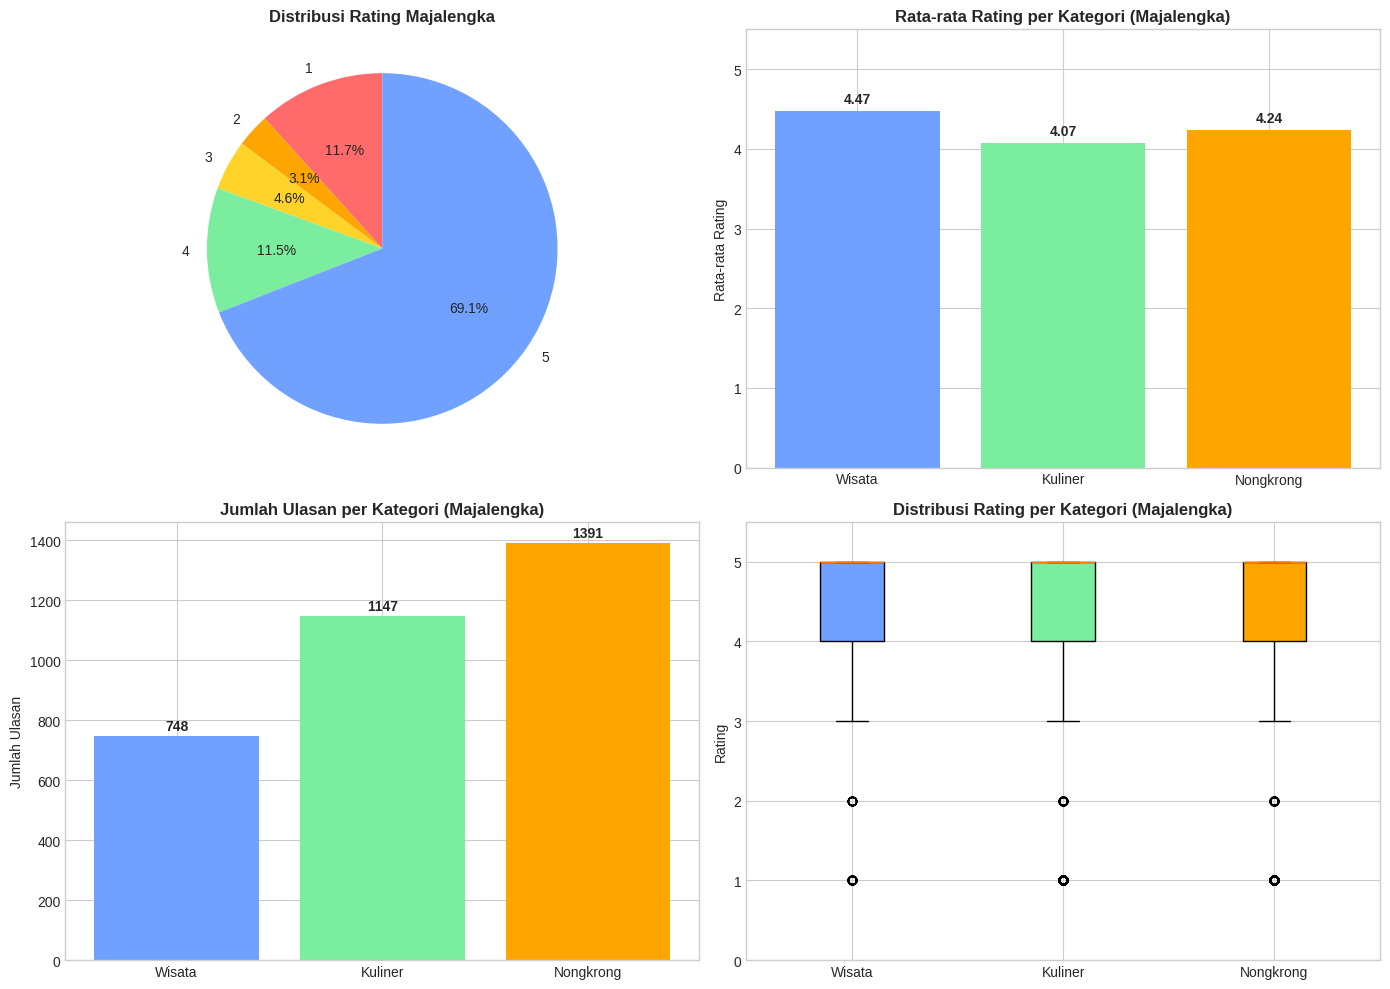

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

all_reviews = pd.concat([
    df_wisata_reviews,
    df_kuliner_reviews,
    df_nongkrong_reviews
], ignore_index=True)

# setting style
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(14, 10))

# 1. distribusi rating (pie chart)
ax1 = fig.add_subplot(2, 2, 1)
rating_counts = all_reviews['rating'].value_counts().sort_index()
colors = ['#ff6b6b', '#ffa502', '#ffd32a', '#7bed9f', '#70a1ff']
wedges, texts, autotexts = ax1.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%',
                                    colors=colors[:len(rating_counts)], startangle=90)
ax1.set_title('Distribusi Rating Majalengka', fontsize=12, fontweight='bold')

# 2. rata-rata rating per kategori (bar chart)
ax2 = fig.add_subplot(2, 2, 2)
kategori_rating = {
    'Wisata': df_wisata_reviews['rating'].mean(),
    'Kuliner': df_kuliner_reviews['rating'].mean(),
    'Nongkrong': df_nongkrong_reviews['rating'].mean()
}
bars = ax2.bar(kategori_rating.keys(), kategori_rating.values(), color=['#70a1ff', '#7bed9f', '#ffa502'])
ax2.set_ylim(0, 5.5)
ax2.set_ylabel('Rata-rata Rating')
ax2.set_title('Rata-rata Rating per Kategori (Majalengka)', fontsize=12, fontweight='bold')
for bar, val in zip(bars, kategori_rating.values()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.2f}', ha='center', fontweight='bold')

# 3. jumlah ulasan per kategori (bar chart)
ax3 = fig.add_subplot(2, 2, 3)
kategori_jumlah = {
    'Wisata': len(df_wisata_reviews),
    'Kuliner': len(df_kuliner_reviews),
    'Nongkrong': len(df_nongkrong_reviews)
}
bars = ax3.bar(kategori_jumlah.keys(), kategori_jumlah.values(), color=['#70a1ff', '#7bed9f', '#ffa502'])
ax3.set_ylabel('Jumlah Ulasan')
ax3.set_title('Jumlah Ulasan per Kategori (Majalengka)', fontsize=12, fontweight='bold')
for bar, val in zip(bars, kategori_jumlah.values()):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, str(val), ha='center', fontweight='bold')

# 4. distribusi rating per kategori (boxplot)
ax4 = fig.add_subplot(2, 2, 4)
data_box = [df_wisata_reviews['rating'], df_kuliner_reviews['rating'], df_nongkrong_reviews['rating']]
bp = ax4.boxplot(data_box, labels=['Wisata', 'Kuliner', 'Nongkrong'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#70a1ff', '#7bed9f', '#ffa502']):
    patch.set_facecolor(color)
ax4.set_ylabel('Rating')
ax4.set_title('Distribusi Rating per Kategori (Majalengka)', fontsize=12, fontweight='bold')
ax4.set_ylim(0, 5.5)

plt.tight_layout()
plt.show()

## **Visualisasi top tempat dan rating tertinggi**

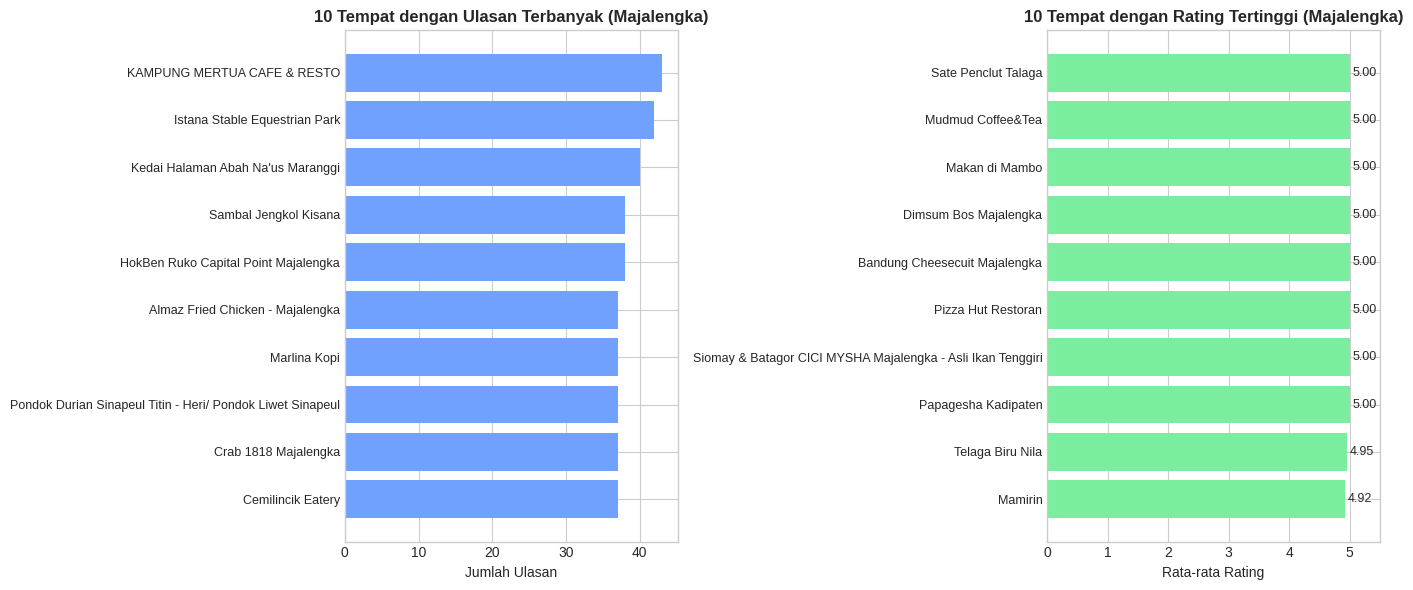

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. 10 tempat dengan ulasan terbanyak
top_places = all_reviews['place_name'].value_counts().head(10)
axes[0].barh(range(len(top_places)), top_places.values, color='#70a1ff')
axes[0].set_yticks(range(len(top_places)))
axes[0].set_yticklabels(top_places.index, fontsize=9)
axes[0].set_xlabel('Jumlah Ulasan')
axes[0].set_title('10 Tempat dengan Ulasan Terbanyak (Majalengka)', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()

# 2. rata-rata rating per tempat (top 10)
avg_rating_per_place = all_reviews.groupby('place_name')['rating'].mean().sort_values(ascending=False).head(10)
bars = axes[1].barh(range(len(avg_rating_per_place)), avg_rating_per_place.values, color='#7bed9f')
axes[1].set_yticks(range(len(avg_rating_per_place)))
axes[1].set_yticklabels(avg_rating_per_place.index, fontsize=9)
axes[1].set_xlabel('Rata-rata Rating')
axes[1].set_title('10 Tempat dengan Rating Tertinggi (Majalengka)', fontsize=12, fontweight='bold')
axes[1].set_xlim(0, 5.5)
axes[1].invert_yaxis()

# tambahkan nilai di ujung bar
for bar, val in zip(bars, avg_rating_per_place.values):
    axes[1].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()